In [3]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np


In [4]:
np.random.seed(0)
n = 100

x1 = np.random.randn(n)
x2 = x1 + 0.01 * np.random.randn(n) 

X = np.column_stack([x1, x2])
y = 2 * x1 - 2 * x2 + 0.5 * np.random.randn(n)


In [5]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0))
])

model.fit(X, y)

print("Ridge coefficients:", model.named_steps["ridge"].coef_)
print("Intercept:", model.named_steps["ridge"].intercept_)


Ridge coefficients: [0.01605395 0.01626074]
Intercept: -0.03125638969478832


In [6]:
from sklearn.linear_model import LinearRegression

ols = Pipeline([
    ("scaler", StandardScaler()),
    ("ols", LinearRegression())
])

ols.fit(X, y)

print("OLS coefficients:", ols.named_steps["ols"].coef_)
print("Ridge coefficients:", model.named_steps["ridge"].coef_)


OLS coefficients: [-0.18230992  0.21624039]
Ridge coefficients: [0.01605395 0.01626074]


In [8]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

model_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.1))   # alpha = λ
])

model_lasso.fit(X, y)

print("Lasso coefficients:", model_lasso.named_steps["lasso"].coef_)
print("Intercept:", model_lasso.named_steps["lasso"].intercept_)


Lasso coefficients: [0. 0.]
Intercept: -0.03125638969478832


In [9]:
from sklearn.linear_model import ElasticNet

model_en = Pipeline([
    ("scaler", StandardScaler()),
    ("elastic", ElasticNet(alpha=0.1, l1_ratio=0.5))
])

model_en.fit(X, y)

print("Elastic Net coefficients:", model_en.named_steps["elastic"].coef_)
print("Intercept:", model_en.named_steps["elastic"].intercept_)


Elastic Net coefficients: [0. 0.]
Intercept: -0.03125638969478832


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler

np.random.seed(0)

n = 100
x1 = np.random.randn(n)
x2 = x1 + 0.01 * np.random.randn(n)  # correlated feature
x3 = np.random.randn(n)              # independent feature

X = np.column_stack([x1, x2, x3])
y = 3*x1 - 3*x2 + 0.5*x3 + 0.5*np.random.randn(n)

# Scale features (critical)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [11]:
alphas = np.logspace(-3, 2, 50)

ridge_coefs = []
lasso_coefs = []
enet_coefs = []

for a in alphas:
    ridge = Ridge(alpha=a)
    lasso = Lasso(alpha=a, max_iter=10000)
    enet  = ElasticNet(alpha=a, l1_ratio=0.5, max_iter=10000)

    ridge.fit(X_scaled, y)
    lasso.fit(X_scaled, y)
    enet.fit(X_scaled, y)

    ridge_coefs.append(ridge.coef_)
    lasso_coefs.append(lasso.coef_)
    enet_coefs.append(enet.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)
enet_coefs  = np.array(enet_coefs)


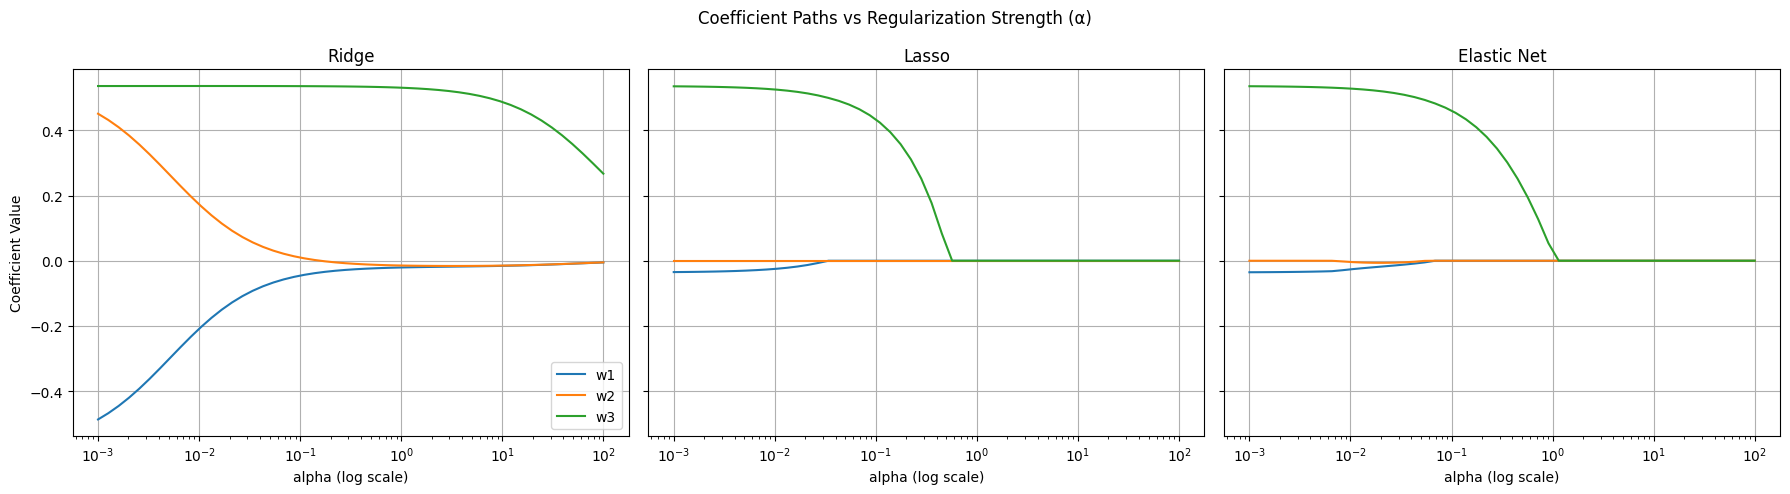

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

models = [
    (ridge_coefs, "Ridge"),
    (lasso_coefs, "Lasso"),
    (enet_coefs,  "Elastic Net")
]

for ax, (coefs, title) in zip(axes, models):
    for i in range(coefs.shape[1]):
        ax.plot(alphas, coefs[:, i], label=f"w{i+1}")
    ax.set_xscale("log")
    ax.set_xlabel("alpha (log scale)")
    ax.set_title(title)
    ax.grid(True)

axes[0].set_ylabel("Coefficient Value")
axes[0].legend(loc="best")

plt.suptitle("Coefficient Paths vs Regularization Strength (α)")
plt.tight_layout()
plt.show()
